In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:


import blackjax
import jax
import jax.numpy as jnp

# Set device to CPU
jax.config.update("jax_platform_name", "cpu")

import matplotlib.pyplot as plt

from probjax.inference.filtering.particle_filter import ParticleFilter

In [3]:
from probjax.inference.smc.resampling import resample_smoothed, resample_systematic

In [4]:

N = 1000
particles = jax.random.normal(jax.random.PRNGKey(0), (N,1))
weights = jax.scipy.stats.norm.pdf(particles, loc=0.0, scale=0.1).sum(axis=1)
weights = weights / jnp.sum(weights)


W0303 10:28:24.969640 1781382 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


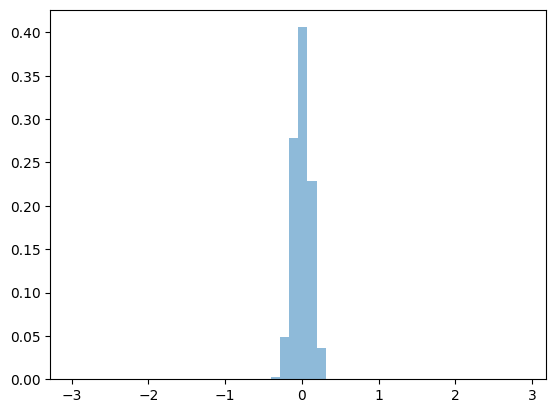

In [5]:
# new_particles, new_log_weights,_ = resample_systematic(jax.random.PRNGKey(0), jnp.log(weights), particles)
# new_particles, new_log_weights,_ = resample_ot(jax.random.PRNGKey(0), jnp.log(weights), particles, eps=0.5, inner_iterations=1, max_iter=2)
new_particles, new_log_weights,_ = resample_smoothed(jax.random.PRNGKey(0), jnp.log(weights), particles, alpha=0.8)

_ = plt.hist(new_particles.flatten(), bins=50, alpha=0.5, weights=jnp.exp(new_log_weights), label="Resampled")

In [6]:
jnp.exp(new_log_weights).sum()

Array(0.9999997, dtype=float32)

In [7]:
key = jax.random.PRNGKey(0)

In [8]:
A = 1.1  # State transition coefficient
H = 1.0   # Observation matrix
Q = 0.1    # Process noise variance
R = 0.01   # Measurement noise variance

def log_likelihood_fn(x,y,t):
    return jax.scipy.stats.norm.logpdf(y,H* x, R)

def transition_fn(key,x,t):
    return A*x + jnp.sqrt(Q)*jax.random.normal(key, shape=x.shape)

In [9]:
def simulate(key, x0, ts):
    x = jnp.asarray(x0)
    xs = [x]
    for t in ts[1:]:
        key, subkey = jax.random.split(key)
        x = transition_fn(subkey, x, t)
        xs.append(x)

    return jnp.stack(xs)

In [10]:
num_time_points = 50
ts = jnp.linspace(0, 50, num_time_points)
xs = jax.vmap(simulate, in_axes=(0,None,None))(jax.random.split(key, 100), 0., ts)

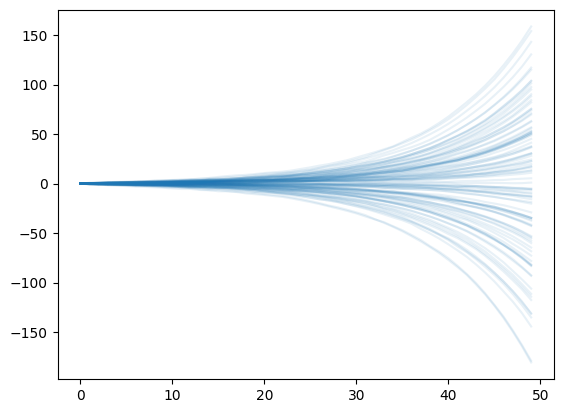

In [11]:
_ = plt.plot(xs.T, alpha=0.1, color="C0")

In [12]:
xs.shape

(100, 50)

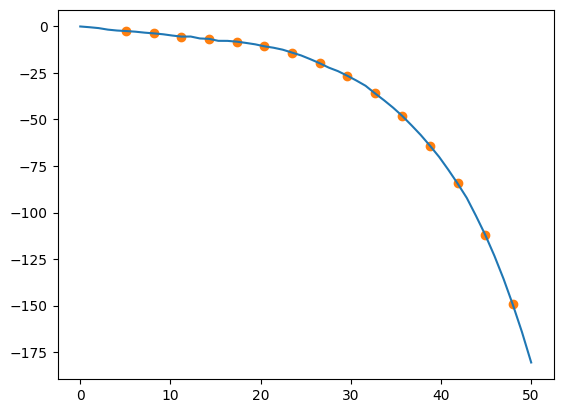

In [13]:
observe_every = 3
start_at = 5
x_o = xs[0,start_at::observe_every]
t_o = ts[start_at::observe_every]
plt.scatter(t_o, x_o, color="C1")
plt.plot(ts, xs[0,:], color="C0")

In [14]:
from probjax.inference.filter_smooth import filter, filter_log_likelihood

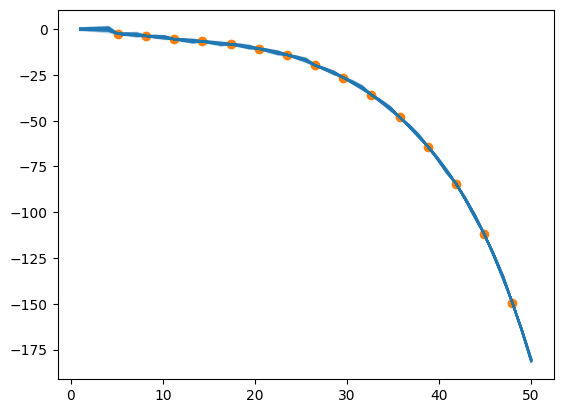

In [15]:
#resample = lambda *args: resample_ot(*args, min_iter=3,max_iter=3, eps=0.5, inner_iterations=3)
resample = lambda *args: resample_systematic(*args)
#resample = lambda *args: resample_smoothed(*args, alpha=0.8)
#kernel = jax.jit(build_kernel(log_likelihood_fn,transition_fn,resample_fn=resample, unbiased_gradients=False))
kernel = ParticleFilter(log_likelihood_fn,transition_fn, resample_criterion=lambda x: True)
particles = jnp.zeros((N,))
filtered_particles = filter(jax.random.PRNGKey(0), ts, t_o, x_o, kernel, particles)
plt.plot(ts[1:], filtered_particles[:, :100], alpha=0.1, color="C0")
plt.scatter(t_o,x_o, color="C1")

In [16]:
def build_log_posterior_density_fn(ts, t_o, x_o):


    def log_posterior_density_fn(A, key):
        key1, key2 = jax.random.split(key)
        particles = jnp.zeros((1000,))
        def transition_fn(key,x,t):
            return A*x + jnp.sqrt(Q)*jax.random.normal(key, shape=x.shape)
        kernel = ParticleFilter(log_likelihood_fn,transition_fn)
        log_Z = filter_log_likelihood(key2, ts, t_o, x_o, kernel, particles)
        return log_Z.sum() + jax.scipy.stats.norm.logpdf(A).sum()

    return log_posterior_density_fn

In [17]:
from probjax.inference.mcmc.slice import slice

In [18]:
log_density_fn = jax.jit(build_log_posterior_density_fn(ts, t_o, x_o))

In [19]:
def key_proposal(key):
    return jax.random.split(key)[-1]


def key_logpdf(*_input):
    return 1.0


A0 = jnp.array([0.1])
rng0 = jax.random.PRNGKey(1)

log_density_fn1 = lambda A: log_density_fn(A, rng0)
state1 = slice.init(A0, log_density_fn1, rng0)
log_density_fn2 = lambda key: log_density_fn(state1.position, key)
state2 = blackjax.irmh.init(rng0, log_density_fn2)

kernel1 = slice.build_kernel()
kernel2 = blackjax.irmh.build_kernel()

@jax.jit
def latent_gibbs(key, state1, state2):
    subkey1, subkey2 = jax.random.split(key, 2)
    log_density_fn1 = lambda x: log_density_fn(x, state2.position)
    state1, info1 = kernel1(subkey1, state1, log_density_fn1, step_size=1e-1)

    log_density_fn2 = lambda x: log_density_fn(state1.position, x)
    state2, info2 = kernel2(
        subkey2,
        state2,
        log_density_fn2,
        proposal_distribution=key_proposal,
        proposal_logdensity_fn=key_logpdf,
    )

    return (state1, state2), (info1, info2)


key = jax.random.PRNGKey(2)


TypeError: init() got multiple values for argument 'rng_key'

In [ ]:
samples = []
for _ in range(5000):
    key, subkey = jax.random.split(key)
    (state1, state2), _ = latent_gibbs(subkey, state1, state2)
    samples.append(state1.position)


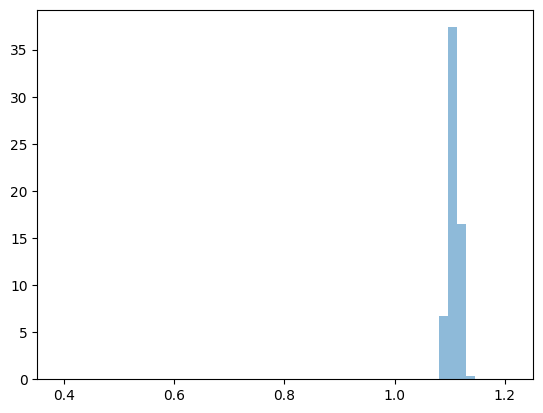

In [ ]:
_ = plt.hist(jnp.concatenate(samples), bins=50, alpha=0.5, density=True)